In [9]:
from sim_loader.abacus_io import AbacusSummitSim
from hod import HOD
# from sim_loader import setup_logging
import numpy as np
import matplotlib.pyplot as plt
# setup_logging()
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
}
test=AbacusSummitSim(**default_abacus_param)

HOD_obj = HOD(base_catalog=test, tracers='LRG', use_particles=True)


[000188.00]  08-11 15:06 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000188.00]  08-11 15:06 AbacusSummitSim              INFO     Load Compaso catalogue from /home/antoine/Bureau/Transfert/postdoc/Abacus_sims/small/AbacusSummit_small_c000_ph3000/halos/z0.500 with particles...
[000191.53]  08-11 15:06 AbacusSummitSim              INFO     Done took 00:00:03
[000191.53]  08-11 15:06 AbacusSummitSim              INFO     Compute required columns...
[000191.61]  08-11 15:06 AbacusSummitSim              INFO     Done took 00:00:00
[000191.61]  08-11 15:06 HOD                          INFO     Initializing HOD.
[000191.62]  08-11 15:06 HOD                          INFO     Set number of threads to 18
[000191.62]  08-11 15:06 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology


In [10]:
HOD_obj.compute_training_v2(test_set=True)

[000191.63]  08-11 15:06 HOD                          INFO     Initializing HOD.
[000191.64]  08-11 15:06 HOD                          INFO     Creating Hammersley sample for test set...
Creation-type sampling will be used.
Sampling type:  creation 



In [ ]:
import numpy as np
import os
import torch
from torch import nn
import glob
from pycorr.utils import cov_to_corrcoef
from torch.utils.data import Dataset, random_split, DataLoader, TensorDataset
from typing import OrderedDict
from torch.optim.lr_scheduler import ReduceLROnPlateau
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA']   = '1'   # optional, for device-side asserts
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = "cpu"


class Normalizer:
    def __init__(self, X, y, log_transform=False):
        self.log_transform = log_transform

        # Optionally transform the output space
        if log_transform:
            y = np.arcsinh(y)

        # Compute statistics
        self.mean_X = np.mean(X.tolist(), axis=0)
        self.std_X  = np.std(X .tolist(), axis=0)

        self.mean_y = y.mean(axis=0)
        self.std_y  = y.std(axis=0)

    def normalize_x(self, X):
        return (X - self.mean_X) / self.std_X

    def normalize_y(self, y):
        if self.log_transform:
            y = np.arcsinh(y)
        return np.nan_to_num((y - self.mean_y) / self.std_y)

    def denormalize_y(self, y_norm, var_norm=None):
        y = y_norm * self.std_y + self.mean_y

        if var_norm is not None:
            var = var_norm * (self.std_y ** 2)
        else:
            var = None

        if self.log_transform:
            y = np.sinh(y)

        return y, var

    def denormalize_x(self, x_pred_norm):
        return x_pred_norm * self.std_X + self.mean_X


class Training_DatasetManager(Dataset):

    def __init__(self, dir_path:str, path_to_test_files=None, stats = ['wp', 'xi'], log_transform=False, seed=None):
        self.dir_path = dir_path
        self.files = [os.path.join(self.dir_path,f) for f in os.listdir(self.dir_path) if f.endswith(".npy")] # Get the name of all the files in the directory
        self.files.sort() # Sort the files to have a reproducible order
        self.data = [] # This will be used for the storage of the data in memory for the training
        self.seed = seed if seed is not None else np.random.randint(0, 2**32 - 1)
        self.generator = torch.Generator().manual_seed(self.seed)
        self.sep = {} # Value of x (rp and s)
        # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = torch.device(DEVICE)

        self.stats = stats
        if path_to_test_files is not None:
            print(f"Loading test files from {path_to_test_files}")
            self.path_to_test_files = [os.path.join(path_to_test_files,f) for f in os.listdir(path_to_test_files) if f.endswith(".npy")] # Get the name of all the files in the directory
            self.path_to_test_files.sort() # Sort the files to have a reproducible order
        
        self.idx = []
        self.log_transform = log_transform

        self.X_training, self.y_training, self.data_dict = self.load_data()

        if self.log_transform :
            self.min_y_train_value = self.y_training.min()
            self.y_training = np.log10(self.y_training - self.min_y_train_value)
            

        # Normalisation min-max
        # self.normalise_x()
        # self.normalise_y()
        self.normalizer = Normalizer(self.X_training, self.y_training, log_transform=self.log_transform)
        self.x_norm = self.normalizer.normalize_x(self.X_training)
        self.y_norm = self.normalizer.normalize_y(self.y_training)
        
        self.data_train = [(self.x_norm[ii], self.y_norm[ii]) for ii in range(self.y_norm.shape[0])]
        if path_to_test_files is not None:
            self.X_test, self.y_test, self.data_dict_test = self.load_data(files=self.path_to_test_files)
            self.x_test_norm = self.normalizer.normalize_x(self.X_test)
            self.y_test_norm = self.normalizer.normalize_y(self.y_test)
        else:
            self.X_test = None
            self.y_test = None
            self.x_test_norm = None


    def load_data(self, files=None):
        """
        Load and merge HOD training data from multiple .npy files.

        Parameters
        ----------
        files : list of str
            List of file paths to .npy files containing HOD training data.

        Returns
        -------
        merged : dict
            Dictionary containing merged HOD parameters and statistics.
            Structure:
                {
                    'hod_fit_param': np.ndarray of shape (n_samples, n_params),
                    'wp': {tracer: [coord_array, xi_array]},
                    'xi_rppi': {tracer: [coord_array1, coord_array2, xi_array]},
                    'xi_smu': {tracer: [coord_array1, coord_array2, xi_array]},
                    'xi_ells': {tracer: [coord_array, xi_array]}
                }
        """

        # ── Load ──────────────────────────────────────────────────────────────────
        raw    = {stat: {} for stat in self.stats}
        params = []

        files = files or self.files
        self.name_arr = None
        for f in files:
            d = np.load(f, allow_pickle=True).item()
            # d.pop('LRG')
            # d.pop('comb_trs')
            # d.pop('param_file')
            missing = [s for s in self.stats if s not in d]
            if missing:
                raise KeyError(f'{f} is missing requested statistics: {missing}')

            params.append(d['hod_fit_param'].tolist())
            if self.name_arr is None:
                self.name_arr = list(d['hod_fit_param'].dtype.names)

            for stat in self.stats:
                for tracer, arrays in d[stat].items():
                    if tracer not in raw[stat]:
                        raw[stat][tracer] = [[] for _ in arrays]
                    for k, arr in enumerate(arrays):
                        raw[stat][tracer][k].append(np.asarray(arr))

        params = np.stack(params, axis=0)
        n      = params.shape[0]

        # ── Stack: last entry is the data, everything before it is a coordinate ───
        merged = {'hod_fit_param': params}

        for stat in self.stats:
            merged[stat] = {}
            for tracer, entries in raw[stat].items():
                merged[stat][tracer] = [stack[0] for stack in entries[:-1]]      # coords
                merged[stat][tracer].append(np.stack(entries[-1], axis=0))       # xi

        # ── Data vector ───────────────────────────────────────────────────────────
        blocks, labels = [], []

        for stat in self.stats:
            for tracer in sorted(merged[stat]):
                flat = merged[stat][tracer][-1].reshape(n, -1)
                blocks.append(flat)
                labels.append((stat, tracer, flat.shape[1]))

        data_vector = np.concatenate(blocks, axis=1)

        edges  = np.cumsum([0] + [lab[2] for lab in labels])
        self.slices = {f'{s}_{t}': slice(edges[j], edges[j+1])
                for j, (s, t, _) in enumerate(labels)}

        # ── keep the coordinate arrays so plotting can split blocks ───
        self.coords = {stat: {tr: merged[stat][tr][:-1]
                              for tr in merged[stat]}
                       for stat in self.stats}
        self.block_shapes = {f'{stat}_{tr}': merged[stat][tr][-1].shape[1:]
                             for stat in self.stats for tr in merged[stat]}

        return merged['hod_fit_param'], data_vector, merged
    
    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.X_training)
    
    def __getitem__(self, idx):
        """Return a sample from the dataset."""
        values, y = self.x_norm[idx], self.y_norm[idx]
    
        return torch.tensor(values, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

    def extract_data(self):
        return torch.tensor(self.x_norm, dtype=torch.float32).to(self.device), torch.tensor(self.y_norm, dtype=torch.float32).to(self.device)

    def get_train_val_sets(self, train_frac=0.8):
        """
        Return the training and validation dataset for the training of the neural net.
        
        PARAMETERS:
        -----------
        train_frac : float 
            Fraction of the dataset to use for training.
    
        RETURN:
        ------
            (train_dataset, val_dataset): deux sous-ensembles TensorDataset
        """
        X, y = self.extract_data()

        dataset = TensorDataset(X, y)
    
        # Split train/val
        train_size = int(train_frac * len(dataset))
        val_size = len(dataset) - train_size
            
        return random_split(dataset, [train_size, val_size], generator=self.generator)
    
    def plot_training_data_distribution(self, show_test=False):
        """
        Plot the distribution of the training data using pair plots.
        This function uses seaborn's pairplot to visualize the relationships between the features in the training dataset. It creates a grid of scatter plots for each pair of features, along with histograms for the individual features on the diagonal. This is useful for understanding the distribution and correlations of the training data.
        """

        import matplotlib.pyplot as plt
        import seaborn as sns
        import pandas as pd

        df = pd.DataFrame(self.X_training, columns=self.name_arr)
        df['set'] = 'train'

        if show_test and self.X_test is not None:
            df_test = pd.DataFrame(self.X_test, columns=self.name_arr)
            df_test['set'] = 'test'
            df = pd.concat([df, df_test], ignore_index=True)

        # sns.pairplot(df, hue='set',
        #      corner=True,                          # drop the redundant upper triangle
        #      diag_kind='hist',                     # 'kde' if the sets overlap heavily
        #      palette={'train': 'C0', 'test': 'C3'},
        #      plot_kws={'s': 12, 'alpha': 0.5, 'edgecolor': 'none'})
        g = sns.PairGrid(df, hue='set', corner=True,
                 palette={'train': 'lightgray', 'test': 'C3'})
        g.map_lower(sns.scatterplot, s=10, alpha=0.4, edgecolor='none')
        g.map_diag(sns.kdeplot, fill=False)
        g.add_legend()
        plt.show()

In [12]:
train = Training_DatasetManager('/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/tmp/training_set', stats = ['xi_rppi'], log_transform=False, path_to_test_files='/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/tmp/training_set/test_set')

Loading test files from /home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/tmp/training_set/test_set


/tmp/ipykernel_29715/1529704818.py:34: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num((y - self.mean_y) / self.std_y)
/tmp/ipykernel_29715/1529704818.py:34: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num((y - self.mean_y) / self.std_y)


In [ ]:
from torch.utils.data import Dataset, random_split, DataLoader, TensorDataset
from matplotlib import pyplot as plt
import numpy as np
import os
import torch
from torch import nn
from torch.utils.data import Dataset, random_split, DataLoader, TensorDataset
from typing import OrderedDict
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
from torch.cuda.amp import autocast, GradScaler


class FCNN(nn.Module):
    """
    Fully Connected Neural Network
    """
    def __init__(self,
                 n_input : int,
                 n_output : int,
                 n_hidden: list[int] =[512, 512, 512, 512],
                 activation_fn = 'ReLU',
                 loss: str = 'rmse',
                 learning_rate: float = 1.e-3,
                 dropout_rate: float = 0.0,
                 weight_decay=2.5e-6,
                 device: str = 'cpu',
                 var_loss_weight: float = 1.0,
                 verbose=True,
                 use_std=False
                ):
        """
        Initialize the FCNN model.

        PARAMETERS:
        -----------
        n_input : int
            Number of input features (HOD parameters).
        n_output : int
            Number of output values (e.g. number of wp bins).
        n_hidden : List[int]
            List of hidden layer sizes.
        activation_fn : str
            Activation function name (e.g., 'ReLU', 'SiLU').
        loss : str
            Type of loss function ('mse', 'rmse', 'mae').
        learning_rate : float
            Learning rate for the optimizer.
        dropout_rate : float
            Dropout rate between layers (0.0 disables it).
        device : str
            'cpu' or 'cuda' (for GPU support).
        """
        super().__init__()
        self.n_input = n_input
        self.n_output = n_output
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        self.activation_fn = activation_fn
        self.loss_type = loss
        self.device = torch.device(DEVICE)
        self.dropout_rate = dropout_rate
        self.var_loss_weight = var_loss_weight
        self.weight_decay = weight_decay
        self.use_std = use_std
        
        if self.loss_type == "learned_gaussian":
            self.n_output *= 2 # Prediction of the mean and prediction variance of each bin
        else:
            self.n_output *= 1 # Prediction of the mean of each bin

        self.model = self._build_mlp()
        self.to(self.device) 
        
        self.loss_fn = self._get_loss_fn()
        self.optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

        # *** AMP ***
        self.use_amp = (self.device.type == "cuda")
        self.scaler  = GradScaler(enabled=self.use_amp)

        


    def _get_activation(self, layer_index: int):
        """ Returns the activation function for the given layer index. """
        return getattr(nn, self.activation_fn)()
        

    def _build_mlp(self):
        """
        Build a multi-layer perceptron (MLP) dynamically with optional dropout.
    
        PARAMETERS:
        -----------
        n_input : int
            Number of input features.
        n_hidden : list[int]
            List of hidden layer sizes.
        n_output : int
            Number of output features (e.g. length of wp).
        dropout_rate : float
            Dropout rate to apply after each activation layer (0.0 to disable).
    
        RETURNS:
        --------
        nn.Sequential
            A complete PyTorch MLP model.
        """
        model = nn.Sequential(OrderedDict())  # Create an ordered container for the layers

        last_dim = self.n_input  # Start with input size

        for i, hidden_dim in enumerate(self.n_hidden):
            # Create unique names for layers
            layer_name = f"mlp{i}"
            act_name = f"act{i}"
            dropout_name = f"dropout{i}"
    
            # Linear layer: input → hidden_dim
            linear_layer = nn.Linear(last_dim, hidden_dim)
            # Activation function: e.g., ReLU, SiLU, or LearnedSigmoid
            activation = self._get_activation(i)
    
            # Add layers to the model
            model.add_module(layer_name, linear_layer)
            model.add_module(act_name, activation)
            if self.dropout_rate > 0.0:
                model.add_module(dropout_name, nn.Dropout(self.dropout_rate))
    
            # Update input size for the next layer
            last_dim = hidden_dim
    
        # Final layer: last hidden size → output
        final_layer_name = f"mlp{len(self.n_hidden)}"
        model.add_module(final_layer_name, nn.Linear(last_dim, self.n_output))
    
        return model


    def forward(self, x):
        """
        Forward pass of the neural network.
    
        Returns:
        -------
        If loss is 'learned_gaussian': tuple of (prediction, variance)
        Else: prediction, zeros_like(prediction)
        """
        out = self.model(x)

        if self.loss_type == "learned_gaussian":
            # On sépare le vecteur de sortie en moyenne et variance
            mean, log_var = torch.chunk(out, 2, dim=-1)
            var = nn.functional.softplus(log_var) 
            return mean, var
        else:
            mean = out
            var = torch.zeros_like(mean, device=mean.device)
            return mean, var


    def compute_loss(self, X, y_true):
        """
        Compute the total loss:
        - prediction loss (wp) + supervised std loss (from mocks)
    
        Parameters
         ----------
        X : torch.Tensor
                Input features (batch_size, n_input)
        y_true : torch.Tensor
            Ground truth for wp (batch_size, n_output)
    
        Returns
        -------
        torch.Tensor
            Scalar loss value
        """     
        if self.loss_type == "learned_gaussian":
            preds, var_pred = self.forward(X)
            # loss = nn.GaussianNLLLoss(full=True)(preds, y_true, var_pred)
            # print(var_pred[0].shape, var_pred.shape, preds.shape, y_true[:,0].shape, y_true[:,1].shape)
            # loss = nn.GaussianNLLLoss(full=True)(torch.rand(var_pred.shape, device=self.device)*var_pred+preds, y_true[:,0], y_true[:,1]) # Sample from mean+pred to reduce both
            if self.use_std:
                preds = torch.rand(preds.shape, device=self.device)*var_pred+preds
                loss = nn.GaussianNLLLoss(full=True)(preds, y_true, var_pred)
            else:
                loss = nn.GaussianNLLLoss(full=True)(preds, y_true, var_pred) # Sample from mean+pred to reduce both

        else:
            preds, _ = self.forward(X)
            loss = self.loss_fn(preds, y_true)               
        return loss


    def _get_loss_fn(self):
        """
        Return the appropriate loss function based on self.loss_type.
        """
        if self.loss_type == "mse":
            return nn.MSELoss()
        elif self.loss_type == "rmse":
            return lambda y, y_pred: torch.sqrt(nn.MSELoss()(y, y_pred))
        elif self.loss_type == "mae":
            return nn.L1Loss()
        elif self.loss_type == "learned_gaussian":
            return nn.GaussianNLLLoss(full=True)
        else:   
            raise NotImplementedError(f"Loss '{self.loss_type}' is not implemented.")

    def predict(self, X, no_grad: bool = True):
        """
        Predict output values from input HOD parameters.
    
        PARAMETERS:
        -----------
        X : Tensor
            Input tensor of shape (batch_size, n_input)
        no_grad : bool
            Whether to disable gradient tracking (default: True)
    
        RETURNS:
        --------
        Tensor: Predicted output of shape (batch_size, n_output)
        """
        self.eval()
        X = X.to(self.device)
    
        if no_grad:
            with torch.no_grad():
                preds, var = self.forward(X)
        else:
            preds, var = self.forward(X)
    
        return preds, var



    def train_epoch(self, dataloader):
        self.train()
        total_loss = 0.0
    
        for X_batch, y_batch in dataloader:
            # 1) on déplace les données une seule fois
            X_batch = X_batch.to(self.device, non_blocking=True)
            y_batch = y_batch.to(self.device, non_blocking=True)
    
            self.optimizer.zero_grad(set_to_none=True)
    
            # 2) forward + backward en FP16/BF16 si GPU
            with autocast(enabled=self.use_amp):
                loss = self.compute_loss(X_batch, y_batch)
    
            # 3) mise à jour AMP
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
    
            total_loss += loss.item()
    
        return total_loss / len(dataloader)


    def fit(self,
        train_loader,
        val_loader,
        min_epochs: int = 100,
        max_epochs: int = 5000,
        patience: int = 30,          # plateau patience (early stopping)
        verbose: bool = True,
        optimizer=None):
        """
        Train the model with early stopping based on validation loss.
        The model will train at least `min_epochs`, and at most `max_epochs`.

        Parameters
        ----------
        train_loader : DataLoader
        val_loader   : DataLoader
        min_epochs   : int
            Minimum number of epochs before early stopping is allowed.
        max_epochs   : int
            Maximum number of epochs to train.
        patience     : int
            Number of epochs with no improvement before stopping.
        scheduler    : PyTorch scheduler or None
            If using ReduceLROnPlateau, pass e.g.:
                scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=10)
        """

        if optimizer is not None:
            self.optimizer = optimizer

        # IMPORTANT: create scheduler once
        scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=10)
        # self.scheduler = scheduler

        self.train_losses = []
        self.val_losses   = []

        best_val_loss = float("inf")
        best_state = None
        epochs_no_improve = 0  # for plateau tracking

        start_time = time.time()

        for epoch in range(max_epochs):

            train_loss = self.train_epoch(train_loader)
            val_loss = self.evaluate(val_loader)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch+1}/{max_epochs} - "
                    f"Train: {train_loss:.5f} | Val: {val_loss:.5f}")

            # ---- LR Scheduler step ----
            scheduler.step(val_loss)
    
            # ---- Track best model ----
            if val_loss < best_val_loss - 1e-7:  # small tolerance
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in self.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            # ---- EARLY STOPPING ----
            if epoch + 1 >= min_epochs and epochs_no_improve >= patience:
                if verbose:
                    print(f"\n⛔ Early stopping triggered at {epoch}: no improvement for {patience} epochs.")
                break

        # Restore best weights
        if best_state is not None:
            self.load_state_dict(best_state)

        if verbose:
            print(f"\nTraining completed in {time.time() - start_time:.1f}s "
                f"| Best Val Loss: {best_val_loss:.5f}")


    @torch.no_grad()
    def evaluate(self, dataloader):
        self.eval()
        total_loss = 0.0
    
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(self.device, non_blocking=True)
            y_batch = y_batch.to(self.device, non_blocking=True)
    
            with autocast(enabled=self.use_amp):
                loss = self.compute_loss(X_batch, y_batch)
            total_loss += loss.item()
    
        return total_loss / len(dataloader)

    
    def save_model(self, path: str = "model.pth"):
        """
        Save the model weights to a file.
    
        PARAMETERS:
        -----------
        path : str
            Path to the output file (default: 'model.pth')
        """
        torch.save(self.state_dict(), path)


    def load_model(self, path: str):
        """
        Load model weights from a file.
    
        PARAMETERS:
        ----------- 
        path : str
            Path to the file where weights were saved
        """
        self.load_state_dict(torch.load(path, map_location=self.device))
        self.to(self.device)

    def plot_loss(self):
        """
        Plot the training and validation loss curves.
        """

        if getattr(self, 'train_losses', None) is None or getattr(self, 'val_losses', None) is None:
            raise ValueError("Training and validation losses are not available from a preloaded model.")
        
        fig,ax = plt.subplots(1,1,figsize=(6, 4))
        ax.plot(self.train_losses, label="Training loss")
        ax.plot(self.val_losses, label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")

        ax.set_title(f"Training and Validation Loss \n Loss value at last epoch train {self.train_losses[-1]:.2f}, validation {self.val_losses[-1]:.2f}")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        fig.show()
        

def make_training_dataset(dir_path:str, stats = ['wp', 'xi'], log_transform=False, seed=None, path_to_test_files=None, batch_size=256):
    """
    This function Will creat the training dataset for the training of the neural network.

    PARAMETER:
    ---------
    dataset_path : str
        The path of the training dataset.
    normalization_cst_name : str
        The name of the normalization constants.

    RETURNS:
    --------
    train_loader : 
        Training loader for the training of the neural network.
    val_loader : 
        Validation loader for the training of the neural network.
    """

    train_Dataset = Training_DatasetManager(dir_path, stats=stats, log_transform=log_transform, seed=seed, path_to_test_files=path_to_test_files)

    X, y = train_Dataset.extract_data()
    train_dataset, val_dataset = train_Dataset.get_train_val_sets()
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,                
        shuffle=True,
        num_workers=0,                
        pin_memory=True,                
        persistent_workers=False,
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        persistent_workers=False,
    )
    

    # No normalisation cst

    return train_Dataset, train_loader, val_loader


def train_model(
    train_loader,
    val_loader,
    n_hidden:list[int] = [128,128,128],
    Activation_fn:str = "SiLU", 
    Learning_rate:float = 3e-4, 
    Dropout_rate:float = 0.05, 
    weight_decay=2.5e-6,
    min_epochs:int = 100,
    max_epochs:int = 5000,
    loss="learned_gaussian",
    path_to_model:str = None,
    Model_saving_path:str = None,
    use_std=False):
    """
    This function train the neural network.
    
    PARAMETERS:
    -----------
    Model_saving_path : str
        The saving path of the model.
    train_loader :
        The training loader.
    val_loader : 
        The validation loader.
    n_hidden_layers : int
        The number of hidden layers in the model.
    Activation_fn : str
        The activation function of the model.
    Learning_rate : float
        The learning rate of the model.
    Dropout_rate : float
        The dopout rate of the model.
    Train_epoch : int
        The number of epoch of training.
    

    RETURNS:
    -------
    model : 
        The trained model ready to be used
    Train_losses : 
        The values of the training losses over the epoch of training.
    val_losses : 
        The values of the validation losses over the epoch of training.
    """
    device = torch.device(DEVICE)
    # device = 'cpu'
    nb_outpout = train_loader.dataset[0][1].shape[-1]
    nb_input = train_loader.dataset[0][0].shape[-1]
    
    # Hidden_layers = []

    # for i in range(n_hidden_layers):
    #     Hidden_layers.append(nb_nerons)
    
    model = FCNN(
        n_input=nb_input,
        n_output=nb_outpout,
        n_hidden=n_hidden,
        activation_fn=Activation_fn,
        loss=loss,
        learning_rate=Learning_rate,
        dropout_rate=Dropout_rate,
        weight_decay=weight_decay,
        device=device,
        use_std=use_std
    ).to(device)

    if path_to_model is not None and os.path.isfile(path_to_model):
        model.load_model(path_to_model)
        print(f"Loaded model weights from {path_to_model}")
        return model
        
    
    # optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2.5e-6)
    
    # scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
        
    model = torch.compile(model)    

    
    model.fit(
        train_loader, val_loader, min_epochs=min_epochs, max_epochs=max_epochs)
    
    if Model_saving_path is not None:
        model.save_model(Model_saving_path)

    return model







AttributeError: module 'torch' has no attribute 'Module'

In [1]:
from fit_functions.FCNN_utils import make_training_dataset, train_model
dataset_path = '/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/tmp/training_set'
testset_path='/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/tmp/training_set/test_set'

train_Dataset, train_loader, val_loader = make_training_dataset(dataset_path, stats=['wp', 'xi_ells'], log_transform=False, seed=421, batch_size=256, path_to_test_files=testset_path)
model = train_model(train_loader=train_loader, min_epochs=100, val_loader=val_loader, use_std=True,  
                                              Activation_fn="SiLU")

# model, train_losses, val_losses = train_model(train_loader=train_loader, min_epochs=100, val_loader=val_loader, n_hidden=n_hidden, weight_decay=weight_decay, Dropout_rate=dr, Learning_rate=lr, use_std=True, 
#                                               Activation_fn="SiLU", path_to_model='/home/antoine/Bureau/Transfert/postdoc/HOD/Cosmological_emulator_ELGs/model_LRG_SHOD_6p_z0.5_highbase_zp+xi+ds.pth')

Loading test files from /home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/tmp/training_set/test_set


/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/fit_functions/FCNN_utils.py:1728: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = GradScaler(enabled=self.use_amp)
/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/fit_functions/FCNN_utils.py:1900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):
/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/fit_functions/FCNN_utils.py:2003: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


Epoch 1/5000 - Train: 1.65169 | Val: 1.19673
Epoch 11/5000 - Train: 1.64282 | Val: 1.25499
Epoch 21/5000 - Train: 1.59491 | Val: 1.21893
Epoch 31/5000 - Train: 1.56851 | Val: 1.25157
Epoch 41/5000 - Train: 1.50484 | Val: 1.27671
Epoch 51/5000 - Train: 1.50003 | Val: 1.22964
Epoch 61/5000 - Train: 1.49776 | Val: 1.25844
Epoch 71/5000 - Train: 1.49986 | Val: 1.24504
Epoch 81/5000 - Train: 1.47657 | Val: 1.21780
Epoch 91/5000 - Train: 1.46841 | Val: 1.24822

⛔ Early stopping triggered at 99: no improvement for 30 epochs.

Training completed in 0.3s | Best Val Loss: 1.19048


In [2]:
import torch
model.predict(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(model.device), no_grad=True)

(tensor([[ 1.9655e-02, -7.9046e-02, -8.4741e-02,  2.0711e-03, -9.4894e-02,
          -6.9950e-03, -1.2473e-01, -4.8507e-02,  4.9779e-02, -7.4362e-03,
          -8.0163e-02, -9.5351e-02, -9.1254e-02, -1.2170e-02, -1.0598e-01,
          -9.0764e-02,  6.3980e-02,  7.6979e-04, -1.5529e-03,  4.9584e-02,
          -7.8650e-02, -2.0447e-02, -2.9735e-02, -6.4513e-02,  1.2220e-02,
          -4.6376e-02, -1.0372e-01, -9.1881e-03, -3.9212e-02,  3.3447e-02,
          -1.9087e-02, -7.7104e-02, -4.5446e-02, -6.4596e-02,  3.3486e-02,
          -6.5394e-03, -6.1233e-02, -7.3382e-02,  5.4990e-02,  3.2654e-02,
          -9.1999e-02, -5.5475e-02,  4.7511e-02,  3.6441e-02, -7.5620e-02,
          -6.6433e-03, -8.0815e-02,  4.7582e-02,  8.3617e-02, -6.8005e-02,
          -1.7743e-02, -2.2412e-02, -1.5913e-02, -3.5438e-02, -2.2792e-02,
          -1.0778e-01,  4.3800e-02, -2.0748e-02, -2.0559e-02, -1.0251e-02,
          -1.9606e-02, -9.9344e-02, -6.1699e-02, -7.1821e-02, -5.4200e-02,
          -5.9801e-02, -5

(10, 75)


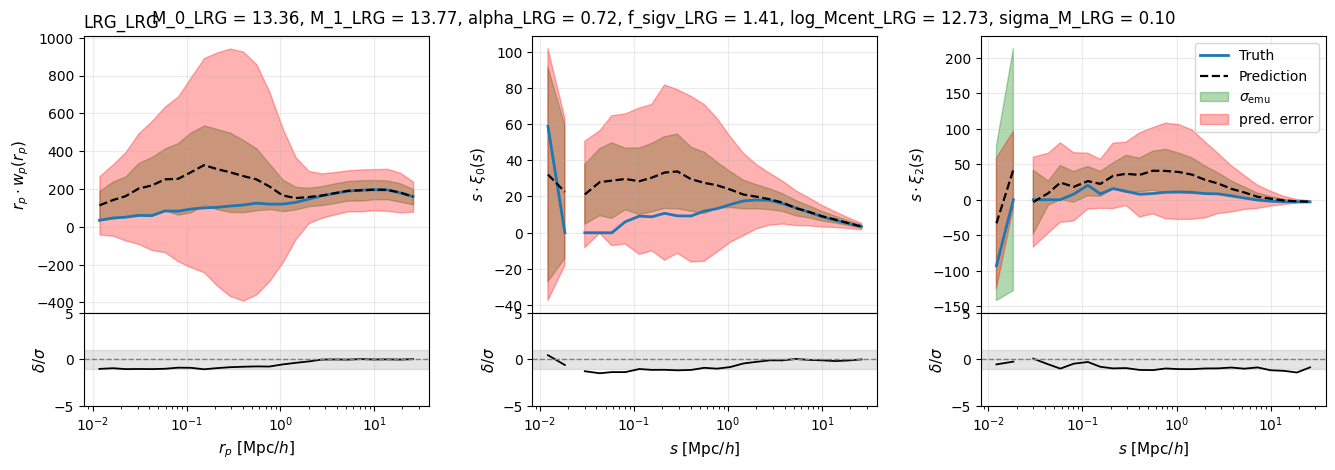

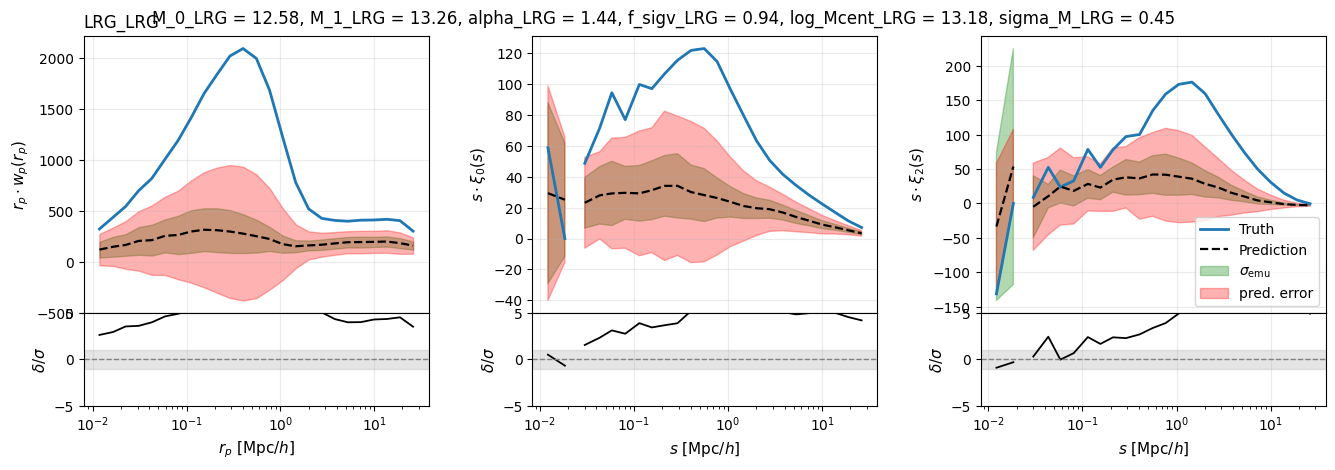

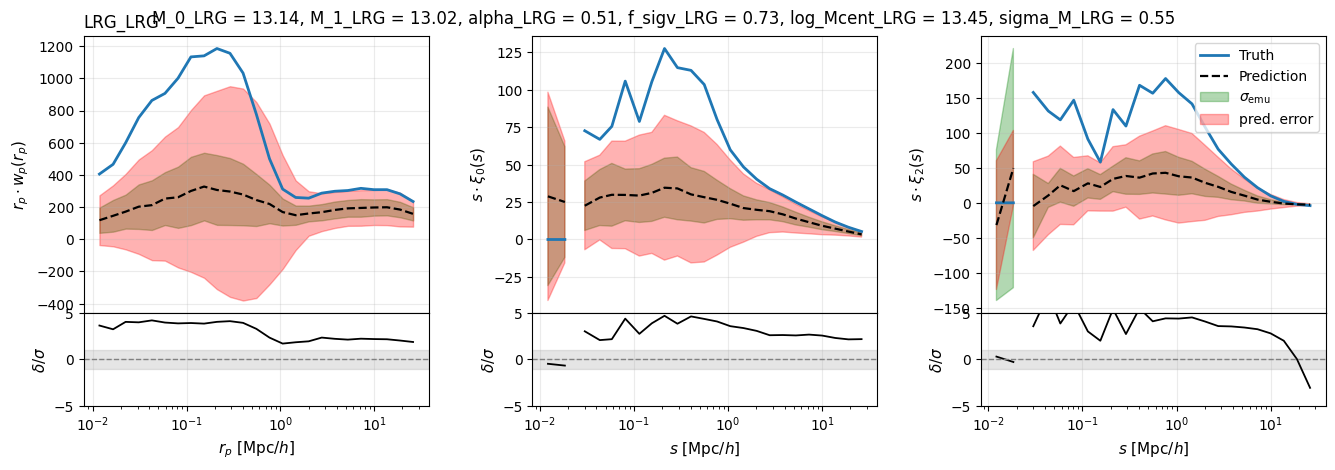

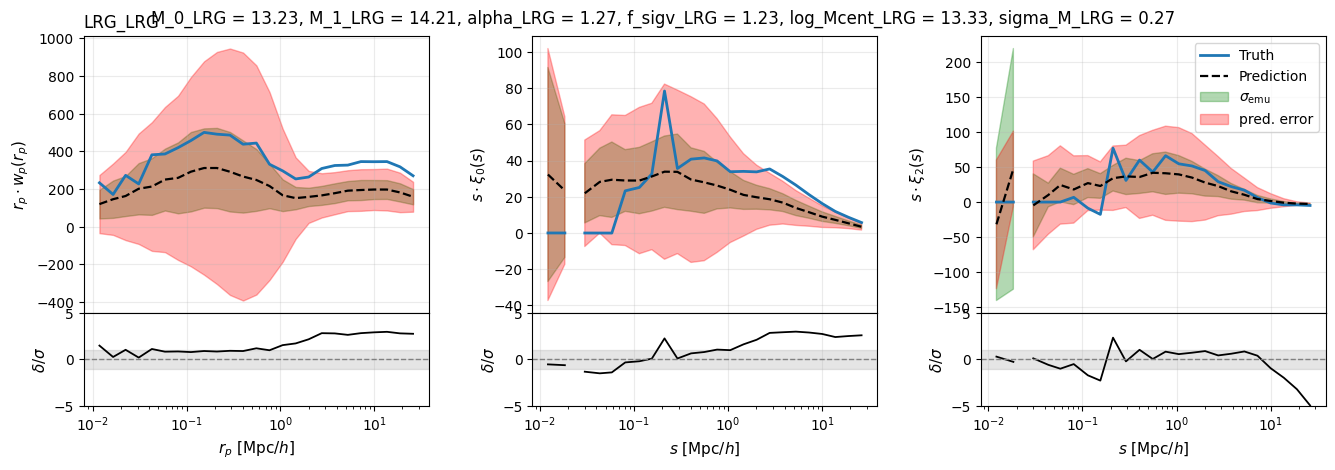

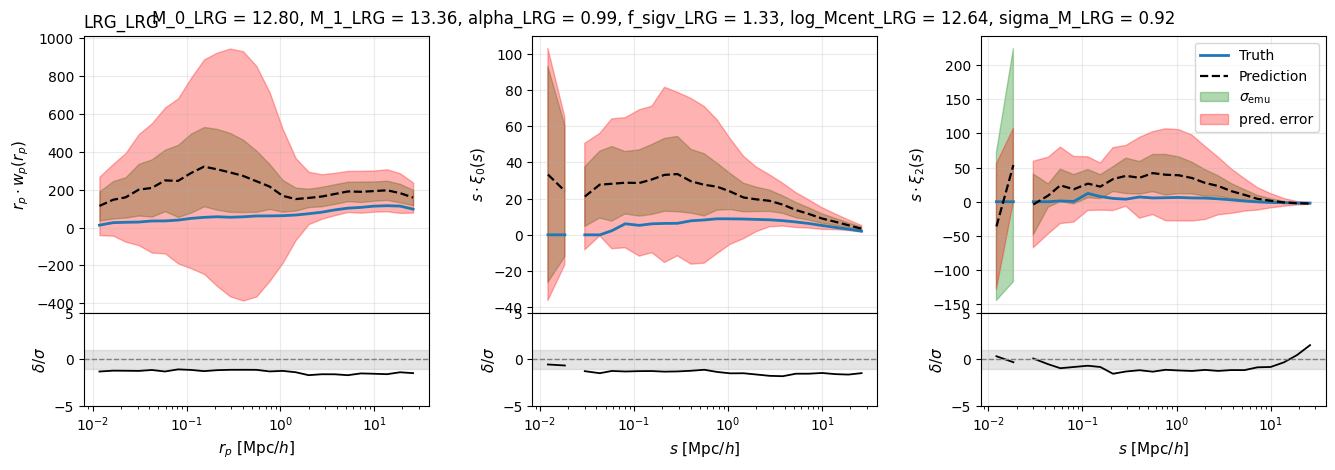

[<Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>]

In [6]:
from fit_functions.plotting_emulator_func import plot_verif 
plot_verif(train_Dataset, model, std_emu=std_emu)                 # auto scale (default)


In [5]:
cov_emu = Uncertanities_computation(model, train_Dataset)
std_emu = np.sqrt(np.diag(cov_emu))

In [3]:
import numpy as np

def Uncertanities_computation(model, train_Dataset):
    """
    Compute the covariance matrix of the prediction errors on the test set.

    Parameters
    ----------
    model : FCNN
        The trained neural network model.
    train_Dataset : Training_DatasetManager
        The dataset manager containing the test data.

    Returns
    -------
    cov : np.ndarray
        Covariance matrix of the prediction errors.
    std_test : np.ndarray
        Standard deviation of the prediction errors.
    """
    Y_test = train_Dataset.y_test
    Y_pred = model.predict(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(model.device), no_grad=True)[0]
    Y_pred = train_Dataset.normalizer.denormalize_y(Y_pred)[0].squeeze().cpu().numpy()
    deltas = Y_pred - Y_test      
    delta_mean = np.mean(deltas, axis=0) 


    deltas = Y_pred - Y_test      
    # deltas = y_pred_norm-train_Dataset.y_test_norm
    delta_mean = np.mean(deltas, axis=0) 
    deltas -= delta_mean 
    cov = np.cov(deltas, rowvar=False, ddof=1) # Use ddof=1 for sample covariance

    return cov

In [ ]:
Y_test = train_Dataset.y_test_norm
Y_pred = model.predict(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(model.device), no_grad=True)
deltas = Y_pred - Y_test      
delta_mean = np.mean(deltas[0], axis=0) 
deltas -= delta_mean

In [64]:
Y_pred = model.predict(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(model.device), no_grad=True)[0]
Y_pred.shape
train_Dataset.normalizer.denormalize_y(Y_pred)[0]

tensor([[ 7.8559e+03,  7.3828e+03,  6.2258e+03,  4.8617e+03,  3.7135e+03,
          3.3392e+03,  2.7800e+03,  2.1816e+03,  1.5594e+03,  1.1751e+03,
          1.0227e+03,  6.1661e+02,  4.4977e+02,  2.3887e+02,  1.4493e+02,
          8.9642e+01,  6.8970e+01,  5.4249e+01,  4.2570e+01,  3.2799e+01,
          2.5078e+01,  1.7822e+01,  1.2944e+01,  8.2888e+00,  5.6259e+00,
          1.8472e+03,  9.7296e+02,  8.9372e+02,  6.0224e+02,  4.5176e+02,
          4.0205e+02,  3.3230e+02,  2.1180e+02,  1.4933e+02,  1.2769e+02,
          1.0065e+02,  7.2117e+01,  4.5368e+01,  2.9700e+01,  1.8339e+01,
          1.2836e+01,  8.4425e+00,  6.0053e+00,  3.7254e+00,  2.4257e+00,
          1.3983e+00,  8.4697e-01,  4.7603e-01,  2.4982e-01,  1.1972e-01,
         -4.0696e+03,  1.7044e+03,  5.8292e+02, -4.0938e+02,  8.7094e+01,
          3.6467e+02,  1.5052e+02,  1.3598e+02,  1.1634e+02,  1.1494e+02,
          1.1066e+02,  6.2993e+01,  5.9345e+01,  4.1467e+01,  2.4564e+01,
          2.0978e+01,  1.1103e+01,  6.

In [113]:
Y_test = train_Dataset.y_test
Y_pred = model.predict(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(model.device), no_grad=True)[0]
Y_pred = train_Dataset.normalizer.denormalize_y(Y_pred)[0].squeeze().cpu().numpy()
deltas = Y_pred - Y_test      
delta_mean = np.mean(deltas, axis=0) 


deltas = Y_pred - Y_test      
# deltas = y_pred_norm-train_Dataset.y_test_norm
delta_mean = np.mean(deltas, axis=0) 

cov = np.zeros((deltas.shape[1], deltas.shape[1]))  

for i in range(len(deltas)):
    delta = deltas[i] - delta_mean              
    cov += np.outer(delta, delta)                   

cov_emu = cov / (len(deltas) - 1)
# cov_emu = np.cov(deltas, rowvar=False,  ddof=0) / (len(deltas) - 1)




In [114]:
Y_test = train_Dataset.y_test
Y_pred = model.predict(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32).to(model.device), no_grad=True)[0]
Y_pred = train_Dataset.normalizer.denormalize_y(Y_pred)[0].squeeze().cpu().numpy()
deltas = Y_pred - Y_test      
delta_mean = np.mean(deltas, axis=0) 


deltas = Y_pred - Y_test      
# deltas = y_pred_norm-train_Dataset.y_test_norm
delta_mean = np.mean(deltas, axis=0) 
deltas -= delta_mean 
cov = np.cov(deltas, rowvar=False, ddof=1) # Use ddof=1 for sample covariance



In [115]:
cov_emu / cov

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

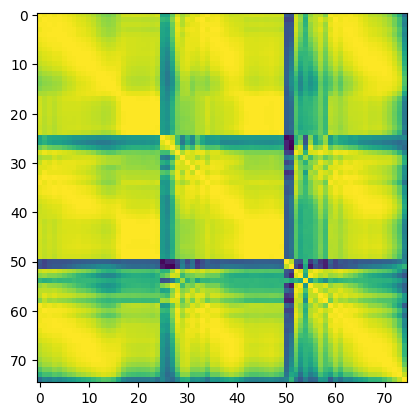

In [46]:
import matplotlib.pyplot as plt
from pycorr.utils import cov_to_corrcoef
corr = cov_to_corrcoef(cov)
plt.imshow(corr, cmap='viridis', interpolation='nearest')

In [ ]:
def Uncertanities_computation(model, train_Dataset):
    """
    This function compute the Emulator's predictiv uncertanities.

    PARAMETERS:
    ----------
    saving_path : str
        The saving path of the model uncertanities.
    covariance_data_path : str
        The path of the directory containing the dataset that will be used for comute the uncertanity of the emulator.
    normalization_cst_cosmo_param_path : str
        The normalization constants for the inputs parameters.
    normalization_cst_data_vector_path : str
        The normalization constants for the output data vector.
    model_path : str
        The path of the model.
    nb_input : int
        The number of input parameters. Initally set to 19, 13 cosmological parameters and 6 HOD parameters.
    nb_outpout : int
        The number of output point. Initially set to 73 but this is for the observables in logarithmic bin only, for linear bin nb_output is 325.
    n_hidden_layers : int
        The number of hidden layers in the model.
    nb_nerons : int
        The number of neurons per hidden layers.
    Activation_fn : str
        The activation function of the model.
    Learning_rate : float
        The learning rate of the model.
    Dropout_rate : float
        The dopout rate of the model.
        

    RETURNS:
    -------
    emulator_cov_matrix : np.2Darray
        The covariance matrix of the emulator uncertanities
    """

    # Loading the covariance dataset
    q05, q95 = np.quantile(train_Dataset.X_training, q=[0.05,0.95], axis=0)
    mask_test_prior = ((train_Dataset.X_test > q05) & (train_Dataset.X_test < q95)).all(axis=1)
    X_test, Y_test = train_Dataset.X_test[mask_test_prior], train_Dataset.y_test[mask_test_prior]


    # Do the predictions for all of the parameters set in the covariance dataset
    # Getting rp and s
    rp = np.array([ 0.04641589,  0.06812921,  0.1       ,  0.14677993,  0.21544347,
        0.31622777,  0.46415888,  0.68129207,  1.        ,  1.46779927,
        2.15443469,  3.16227766,  4.64158883,  6.81292069, 10.        ,
    14.67799268, 21.5443469 , 31.6227766 ])

    rp = (rp[:-1] + rp[1:]) / 2
    s = np.array([  0.21544347,  0.26101572,  0.31622777,  0.38311868,  0.46415888,
            0.56234133,  0.68129207,  0.82540419,  1.        ,  1.21152766,
            1.46779927,  1.77827941,  2.15443469,  2.61015722,  3.16227766,
            3.83118685,  4.64158883,  5.62341325,  6.81292069,  8.25404185,
            10.        , 12.11527659, 14.67799268, 17.7827941 , 21.5443469 ,
            26.10157216, 31.6227766 ])
        
    X_test_norm = torch.tensor(train_Dataset.x_test_norm[mask_test_prior], dtype=torch.float32)
    y_pred_norm  = model.predict(X_test_norm, no_grad=True)[0].squeeze().cpu().numpy()
    Y_pred = train_Dataset.denormalise_y(y_pred_norm)


    
    deltas = Y_pred - Y_test      
    # deltas = y_pred_norm-train_Dataset.y_test_norm
    delta_mean = np.mean(deltas, axis=0) 
    
    cov = np.zeros((deltas.shape[1], deltas.shape[1]))  
    
    for i in range(len(deltas)):
        delta = deltas[i] - delta_mean              
        cov += np.outer(delta, delta)                   
    
    cov_emu = cov / (len(deltas) - 1)
    cov_emu = np.cov(deltas, rowvar=False,  ddof=0) / (len(deltas) - 1)
    
    return cov_emu